## Random Forest Model on Personal Transaction Data
#### Aleksa Marie Ocampo
#### CS 549 Machine Learning Spring 2026

In [1]:
# data loading script with test splits
import sys
sys.path.insert(0, "../data")

from data_loading import load_train_test_split
X_train, X_test, y_train, y_test, feature_cols = load_train_test_split()

print("train:", X_train.shape, y_train.shape)
print("test: ", X_test.shape, y_test.shape) 


train: (8644, 12) (8644,)
test:  (2162, 12) (2162,)


In [2]:
# BASELINE MODEL:
# import random forest model
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestClassifier
base_rf = RandomForestClassifier(
    n_estimators = 100,
    max_depth = None,
    random_state = 24
)

In [3]:
# training the model and making predictions
base_rf.fit(X_train, y_train)
y_pred_base = base_rf.predict(X_test)

Baseline Accuracy: 0.35337650323774283
              precision    recall  f1-score   support

           0       0.38      0.42      0.40       764
           1       0.39      0.43      0.41       745
           2       0.15      0.07      0.09       135
           3       0.27      0.23      0.25       466
           4       0.04      0.02      0.03        52

    accuracy                           0.35      2162
   macro avg       0.25      0.23      0.24      2162
weighted avg       0.34      0.35      0.34      2162



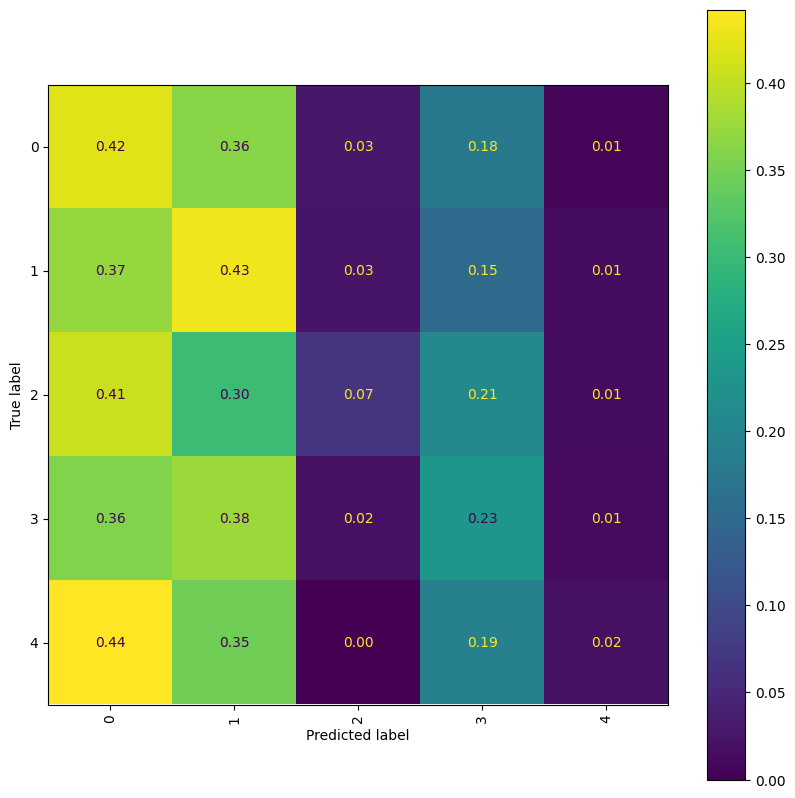

In [4]:
# BASELINE EVALUATION
# evaluate performance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

print("Baseline Accuracy:", accuracy_score(y_test, y_pred_base))
print(classification_report(y_test, y_pred_base))

cm = confusion_matrix(y_test, y_pred_base, normalize='true')

fig, ax = plt.subplots(figsize=(10, 10)) # fix to make more readable

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, values_format=".2f")  # cleaner than default

plt.xticks(rotation=90)
plt.show()

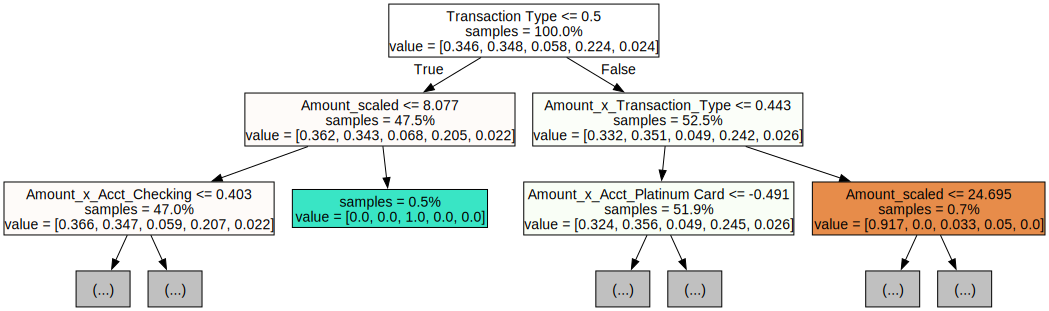

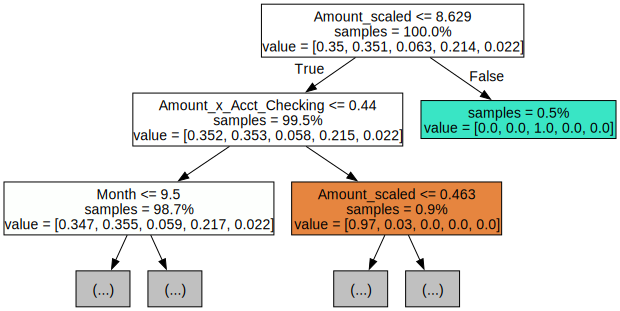

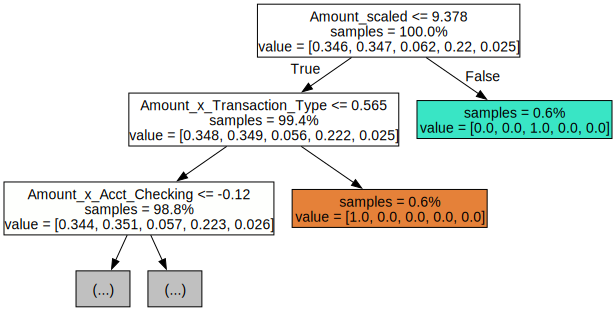

In [5]:
# result visualizations (tree visualization)
from sklearn.tree import export_graphviz
from IPython.display import Image
import graphviz

# first 3 decision trees
for i in range(3):
    tree = base_rf.estimators_[i]
    dot_data = export_graphviz(tree,
                               feature_names=X_train.columns,  
                               filled=True,  
                               max_depth=2, 
                               impurity=False, 
                               proportion=True)
    graph = graphviz.Source(dot_data)
    display(graph)

In [6]:
# hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced"]
}

rf = RandomForestClassifier(random_state=42)

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring="f1_macro", # use f1 instead of accuracy
    verbose=2,
    n_jobs=1
)

search.fit(X_train, y_train)

print("Best parameters:", search.best_params_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
[CV] END class_weight=balanced, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.6s
[CV] END class_weight=balanced, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.6s
[CV] END class_weight=balanced, max_depth=20, max_features=sqrt, min_samples_leaf=1, min_samples_split=10, n_estimators=100; total time=   0.6s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   1.1s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   1.1s
[CV] END class_weight=balanced, max_depth=None, max_features=sqrt, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   1.1s
[CV] END class_weight=balanced, max_depth=20, max_features=log2, min_sam

In [7]:
# final model evaluation
best_rf = search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

Tuned Accuracy: 0.32192414431082333
              precision    recall  f1-score   support

           0       0.39      0.35      0.37       764
           1       0.38      0.36      0.37       745
           2       0.11      0.13      0.12       135
           3       0.26      0.29      0.27       466
           4       0.03      0.06      0.04        52

    accuracy                           0.32      2162
   macro avg       0.24      0.24      0.24      2162
weighted avg       0.33      0.32      0.33      2162



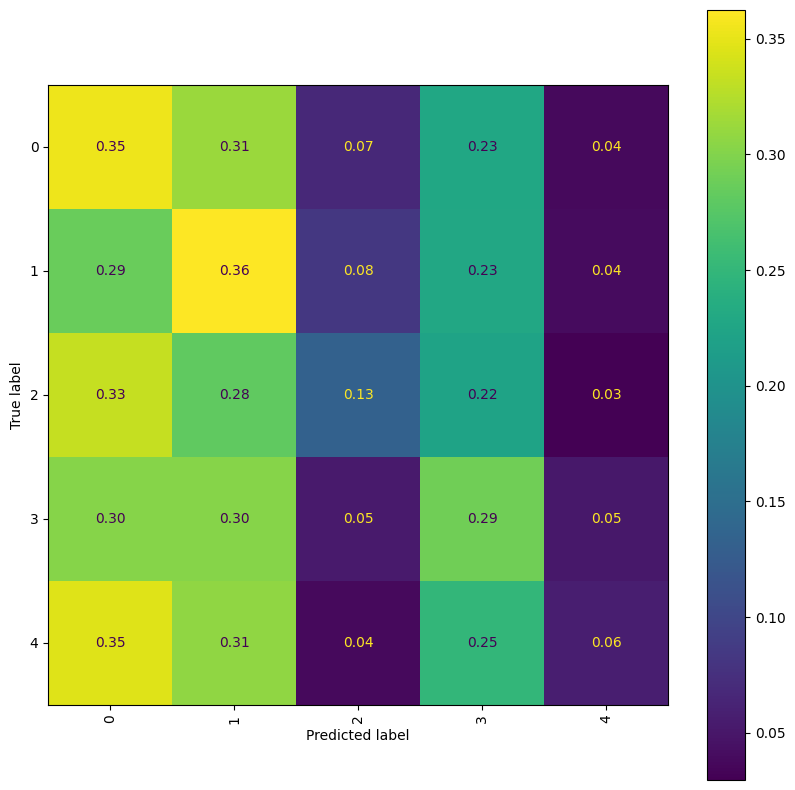

In [8]:
# final model confusion matrix
cm = confusion_matrix(y_test, y_pred_best, normalize='true')
fig, ax = plt.subplots(figsize=(10, 10)) # fix to make more readable

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=ax, values_format=".2f")  # cleaner than default

plt.xticks(rotation=90)
plt.show()